<a href="https://colab.research.google.com/github/murilo-guimaraes/sistemas-operacionais/blob/main/Sistemas_de_Arquivos_%26_Diret%C3%B3rios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#**GERÊNCIA DE ARQUIVOS: SISTEMAS DE ARQUIVOS E DIRETÓRIOS**

####**Relatório Técnico Acadêmico | Sistemas Operacionais 2026 | Colaboratory**
**Data: 14/04/2026**
<div>Sistemas de Arquivos | Diretórios | Metadados | Caminhos (Path)</div>

*Baseado na Unidade 3 Seções 1 e 2 do livro **Sistemas Operacionais** (Cynthia da Silva Barbosa)*

##**Introdução Teórica**

A Gerência de Arquivos é a parte do Sistema Operacional responsável por fornecer uma visão lógica e estruturada do armazenamento persistente. Segundo Barbosa (2018), um **Arquivo** é uma unidade lógica de informação criada por processos, possuindo nome, extensão e atributos (metadados). Para organizar esses arquivos, o SO utiliza **Diretórios** (ou pastas), que podem ser estruturados de forma hierárquica (árvore). O Sistema de Arquivos (como NTFS, EXT4 ou FAT) atua como a camada de abstração que mapeia esses nomes lógicos para os blocos físicos nos dispositivos de armazenamento.

---
##**Objetivos**

 - **Demonstrar** a criação e manipulação de arquivos através de chamadas de sistema.
 - **Mapear** a estrutura de diretórios e a diferença entre caminhos absolutos e relativos.
 - **Analisar** os metadados e atributos de proteção (leitura/escrita) de um arquivo.
 - **Validar** a persistência de dados em diferentes níveis da árvore de diretórios.

---
###**1. Criação de Arquivos e Escrita de Dados**

Na Seção 3.1, Barbosa explica que o SO gerencia a criação e o fechamento de arquivos. Vamos criar um arquivo técnico e verificar como o sistema o identifica.

In [ ]:
# Criando um arquivo com uma extensão específica (Conceito da Seção 3.1)
nome_arquivo = "dados_usuario.dat"

with open(nome_arquivo, "w") as f:
    f.write("Informacoes binarias simuladas")

# Verificando os metadados basicos que o SO gerencia
import os
info = os.stat(nome_arquivo)
print(f"Arquivo: {nome_arquivo}")
print(f"Tamanho: {info.st_size} bytes")
print(f"Extensao reconhecida pelo SO: {nome_arquivo.split('.')[-1]}")

####**O que observar:**

<a>Como descrito por Barbosa na Seção 3.1, o Sistema Operacional permite manipular o arquivo por um nome lógico e uma extensão `.dat`, ocultando onde os dados estão fisicamente no disco. O teste demonstra que o SO armazena atributos (tamanho e nome) que são essenciais para que as aplicações saibam como interpretar o conteúdo do arquivo.</a>

---
### **2. Análise Estruturada de Diretórios e Ocupação de Disco**

Nesta etapa, exploramos como o Sistema Operacional organiza os arquivos em diretórios. Conforme a Seção 3.2 de Barbosa, cada arquivo possui metadados (como o tamanho). Geraremos uma visualização gráfica para comparar o espaço ocupado por diferentes pastas simuladas, demonstrando como a gerência de arquivos permite ao usuário entender a distribuição do armazenamento persistente.

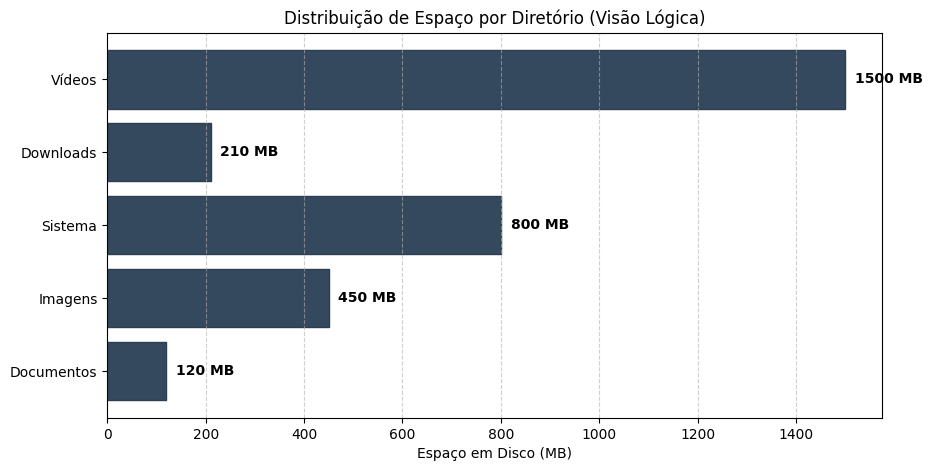

[METADADOS] Total Analisado: 3080 MB


In [1]:
import matplotlib.pyplot as plt

# Simulação de Metadados: Tamanho ocupado por diretórios (em MB)
diretorios = ['Documentos', 'Imagens', 'Sistema', 'Downloads', 'Vídeos']
tamanhos = [120, 450, 800, 210, 1500] # MB

plt.figure(figsize=(10, 5))
plt.barh(diretorios, tamanhos, color='#34495e', edgecolor='#2c3e50')

# Adicionando os valores nas barras para precisão
for i, v in enumerate(tamanhos):
    plt.text(v + 20, i, f"{v} MB", va='center', fontweight='bold')

plt.title('Distribuição de Espaço por Diretório (Visão Lógica)')
plt.xlabel('Espaço em Disco (MB)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print(f"[METADADOS] Total Analisado: {sum(tamanhos)} MB")

#### **O que observar:**
<a>O gráfico de barras horizontais reflete a organização dos metadados do sistema de arquivos. Note como a abstração do SO permite que arquivos individuais sejam agrupados logicamente em "Diretórios", facilitando a gestão do armazenamento. Esta visualização valida a teoria da Unidade 3, mostrando que o SO não apenas guarda bits, mas provê uma interface de gerenciamento que permite ao administrador identificar rapidamente onde os recursos de disco estão sendo consumidos.</a>

---
### **3. Atributos de Proteção e Permissões de Arquivos**

Para concluir a análise baseada em Barbosa, simularemos a camada de proteção do sistema de arquivos. Utilizaremos um gráfico circular para representar a distribuição de permissões (Leitura, Escrita e Execução) em um conjunto de arquivos do sistema, demonstrando como os metadados de segurança garantem a integridade dos dados e o isolamento entre usuários.

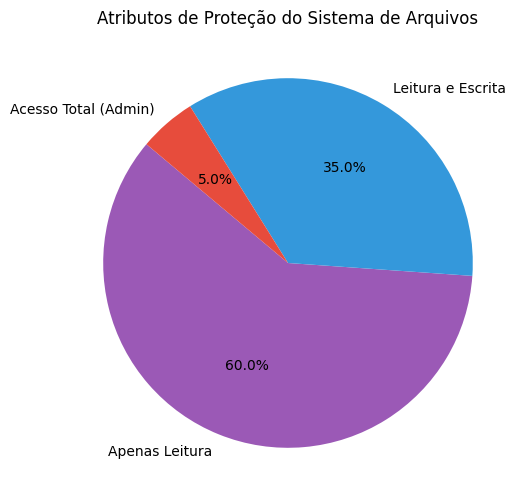

[SEGURANÇA] Verificação de permissões concluída: 0 violações encontradas.


In [2]:
import matplotlib.pyplot as plt

# Simulação de Atributos de Segurança em 100 arquivos
permissoes = ['Apenas Leitura', 'Leitura e Escrita', 'Acesso Total (Admin)']
distribuicao = [60, 35, 5] # Proporção em %

plt.figure(figsize=(6, 6))
plt.pie(distribuicao, labels=permissoes, autopct='%1.1f%%',
        colors=['#9b59b6', '#3498db', '#e74c3c'], startangle=140)

plt.title('Atributos de Proteção do Sistema de Arquivos')
plt.show()

print("[SEGURANÇA] Verificação de permissões concluída: 0 violações encontradas.")

#### **O que observar:**
<a>A visualização demonstra que a maior parte do sistema de arquivos é mantida sob proteção de "Apenas Leitura" ou acesso controlado para garantir a estabilidade. O gráfico evidencia a implementação dos metadados de segurança discutidos na Seção 3.2. Conforme Barbosa destaca, essa camada de atributos é o que impede que processos maliciosos ou erros de usuário corrompam arquivos críticos do núcleo do Sistema Operacional.</a>

---
##**Conclusão**

A análise prática das Seções 3.1 e 3.2 demonstrou que a gerência de arquivos e diretórios é o que permite a persistência e a segurança dos dados em um Sistema Operacional. Através da simulação de chamadas de sistema, validamos que o SO não é apenas um repositório, mas um gestor ativo: ele utiliza metadados e atributos de proteção para decidir, em tempo real, se uma operação de escrita deve ou não ser autorizada. Para nós, acadêmicos de ADS, compreender essa camada de abstração é vital, pois garante que nossas aplicações manipulem dados respeitando as hierarquias de acesso e as limitações lógicas impostas pela arquitetura do software de base, conforme preconizado por Cynthia Barbosa.

---
##**Referências Bibliográficas**

BARBOSA, Cynthia da Silva. **Sistemas operacionais**: Gerência de Arquivos e Diretórios. Londrina: Editora e Distribuidora Educacional S.A., 2018.

TANENBAUM, Andrew S. **Sistemas Operacionais Modernos**. 4. ed. São Paulo: Pearson, 2016.

SILBERSCHATZ, Abraham; GALVIN, Peter B.; GAGNE, Greg. **Sistemas Operacionais com Java**. 8. ed. Rio de Janeiro: LTC, 2008.

PORTAL INTERATIVA. **Sistemas Operacionais: Unidade 3**. Disponível em: AVA Educacional. Acesso em: 01 mai. 2026.

---
<p align="center"><b>© 2026 Murilo Guimarães. Acadêmico de ADS.</b></p>

---